# MuScaRi demo

This notebook demonstrates the workflow for running MuScaRi, including model initialization, data processing, and prediction.

## Setting up the environment (for use in Colab)
Please choose under `Resources` a GPU environment.

The cells below install dependencies on the current Colab kernel. Data and pretrained weights are downloaded automatically from public Hugging Face repositories during loading.
### Installing dependencies

In [ ]:
!git clone https://github.com/vboussange/muscari.git
%cd muscari/
!uv sync;
!uv pip install torch --torch-backend=auto;
!uv pip install -e .
!source .venv/bin/activate


fatal: destination path 'muscari' already exists and is not an empty directory.
Resolved 99 packages in 11ms
Uninstalled 1 package in 0.93ms
 - muscari==0.1.0 (from file:///home/boussang/NNSAR)
Audited 1 package in 4ms
Resolved 94 packages in 167ms                                        
   Building muscari @ file:///home/boussang/NNSAR                      
   Building muscari @ file:///home/boussang/NNSAR              
   Building muscari @ file:///home/boussang/NNSAR              
      Built muscari @ file:///home/boussang/NNSAR              
Prepared 1 package in 549ms                                              
Installed 1 package in 6msm file:///home/boussang/NNSAR)    
 + muscari==0.1.0 (from file:///home/boussang/NNSAR)


<div style="border:2px solid #f44336; background-color:#ffebee; color:#b71c1c; padding:16px; border-radius:6px; font-weight:bold;">
⚠️ Now, <b>restart the session</b> (down arrow next to the tab <code>Run all</code>) to ensure that the environment is set up correctly.
</div>

## Predicting species richness with MuScaRi

In [23]:
import torch
import numpy as np
import xarray as xr
import pandas as pd
from tqdm import tqdm

from muscari import MuScaRiEnsemble
from muscari.plotting import CMAP_BR
from muscari.data_processing.utils_features import EnvironmentalFeatureDataset

def create_raster(gdf, ypred):
    """Converts dataframe features + predictions into a raster."""
    Xy_map = gdf.copy()
    Xy_map["pred"] = ypred
    rast = Xy_map["pred"].to_xarray().sortby(["y", "x"])
    rast = xr.DataArray(
        rast.values,
        dims=["y", "x"],
        coords={"x": rast.x.values, "y": rast.y.values},
        name="pred",
    )
    rast = rast.rio.write_crs("EPSG:3035")
    return rast

def create_features(model, env_dataset, lc_dataset, res):
    """Build model features at a given spatial resolution."""
    resolution = abs(env_dataset.rio.resolution()[0])
    ncells = max(1, int(res / resolution))

    env_vars = [
        v
        for v in env_dataset.data_vars
        if (v in model.feature_names) or (f"std_{v}" in model.feature_names)
    ]
    env_subset = env_dataset[env_vars]
    coarse = env_subset.coarsen(x=ncells, y=ncells, boundary="trim")

    coarse_mean = coarse.mean().rio.write_crs("EPSG:3035")
    coarse_std = coarse.std().rio.write_crs("EPSG:3035")

    df_mean = coarse_mean.to_dataframe()
    df_std = coarse_std.to_dataframe()
    df_std = df_std.rename({col: f"std_{col}" for col in df_std.columns}, axis=1)

    mean_cols = [c for c in df_mean.columns if c in model.feature_names]
    std_cols = [c for c in df_std.columns if c in model.feature_names]
    X_map = pd.concat([df_mean[mean_cols], df_std[std_cols]], axis=1)

    lc_frac_cols = [c for c in model.feature_names if c.startswith("lc_frac_")]
    if lc_frac_cols:
        lc_da = lc_dataset["landcover"].where(lc_dataset["landcover"] >= 0)
        for col in sorted(lc_frac_cols, key=lambda c: int(c.split("_")[-1])):
            idx = int(col.split("_")[-1])
            frac = (lc_da == idx).coarsen(x=ncells, y=ncells, boundary="trim").mean()
            X_map[col] = frac.to_dataframe(name=col)[col]

    X_map = X_map.assign(log_sp_unit_area=np.log(res**2))
    return X_map[model.feature_names]

def batch_predict(model, env_dataset, lc_dataset, res, batch_size=2**12):
    """Predict mean and standard deviation of SR in batches."""
    mean_SR_list = []
    std_SR_list = []
    features = create_features(model, env_dataset, lc_dataset, res)
    total_length = len(features)

    percent_step = max(1, total_length // batch_size // 100)

    for i in tqdm(
        range(0, total_length, batch_size),
        desc="Calculating SR and stdSR",
        miniters=percent_step,
        maxinterval=float("inf"),
    ):
        with torch.no_grad():
            current_batch_size = min(batch_size, total_length - i)
            X = features.iloc[i : i + current_batch_size, :]
            mean_SR_list.append(model.predict_mean_sr_tot(X))
            std_SR_list.append(model.get_std_sr_tot(X))

    mean_SR = np.concatenate(mean_SR_list, axis=0)
    std_SR = np.concatenate(std_SR_list, axis=0)
    return features, mean_SR, std_SR

## Loading model and environmental features from Hugging Face

In [24]:
# Public Hugging Face model repository
MODEL_REPO = "vboussange/muscari"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the pretrained ensemble directly from Hugging Face
model = MuScaRiEnsemble.from_pretrained(MODEL_REPO)
model.to(device)
print(f"Loaded ensemble with {model.n_models} members")
print("Model features:", model.feature_names)

Loaded ensemble with 5 members
Model features: ['bio1', 'pet_penman_mean', 'sfcWind_mean', 'bio12', 'std_bio1', 'std_pet_penman_mean', 'std_sfcWind_mean', 'std_bio12', 'elevation', 'std_elevation', 'log_sp_unit_area']


In [25]:
# Load environmental features.
# If cache files are missing locally, they are fetched automatically from
# the public HF dataset repo: vboussange/muscari-data
feature_dataset = EnvironmentalFeatureDataset()
env_dataset, lc_dataset = feature_dataset.from_hub(use_cache=False)

env_dataset = env_dataset.rio.write_crs("EPSG:3035")
lc_dataset = lc_dataset.rio.write_crs("EPSG:3035")

# Keep only variables needed for this model
env_vars_needed = [
    v for v in env_dataset.data_vars
    if (v in model.feature_names) or (f"std_{v}" in model.feature_names)
]
env_dataset = env_dataset[env_vars_needed]

print("Loaded environmental variables:")
print(list(env_dataset.data_vars))

Loaded environmental variables:
['elevation', 'bio12', 'bio1', 'pet_penman_mean', 'sfcWind_mean']


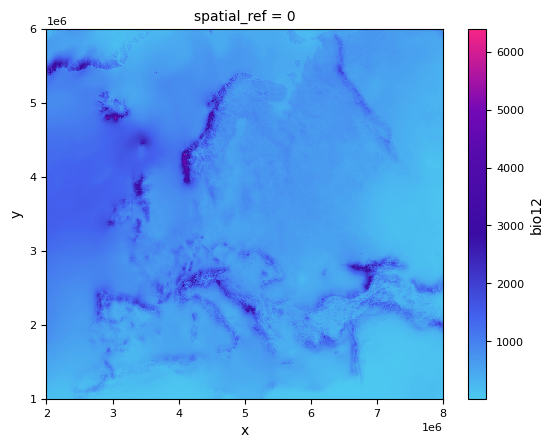

In [ ]:
env_dataset["bio1"].coarsen(x=4, y=4, boundary="trim").mean().plot(cmap=CMAP_BR)

Now we are ready to make predictions!

/home/boussang/deepSAR/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/boussang/deepSAR/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/boussang/deepSAR/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Calculating SR and stdSR: 100%|██████████| 3/3 [00:00<00:00,  8.08it/s]


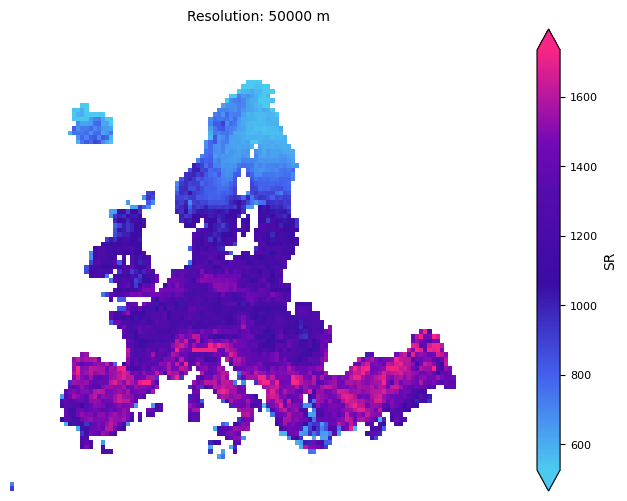

In [27]:
import matplotlib.pyplot as plt

res = 50000  # prediction grid size (meters)
features, SR, std_SR = batch_predict(model, env_dataset, lc_dataset, res)

SR_rast = create_raster(features, SR)

fig, ax = plt.subplots(figsize=(8, 6))
SR_rast = SR_rast.rename("SR")
SR_rast.plot(
    ax=ax,
    cmap=CMAP_BR,
    vmin=SR_rast.quantile(0.01),
    vmax=SR_rast.quantile(0.99),
)
ax.set_title(f"Resolution: {res} m")
ax.set_axis_off()

## Saving raster

In [28]:
model_slug = MODEL_REPO.split("/")[-1]
SR_rast.rio.to_raster(f"SR_raster_{model_slug}_{res:.0f}m.tif")

You can now download the raster under the `Files` tab in Colab.

## Bonus
You can quickly generate another map at a coarser resolution using exactly the same downloaded model and cached environmental datasets.

In [ ]:
res = 20000  # finer grid
features, SR, std_SR = batch_predict(model, env_dataset, lc_dataset, res)

/home/boussang/deepSAR/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


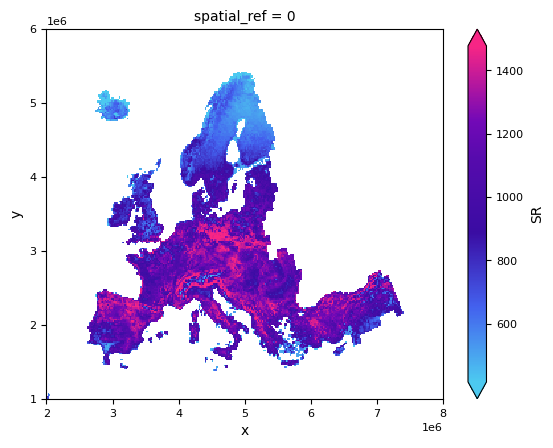

In [ ]:
SR_rast = create_raster(features, SR)
fig, ax = plt.subplots(figsize=(8, 6))
SR_rast.plot(
    ax=ax,
    cmap=CMAP_BR,
    vmin=SR_rast.quantile(0.01),
    vmax=SR_rast.quantile(0.99),
)
ax.set_title(f"Resolution: {res} m")
ax.set_axis_off()